### This sensitivity analysis script serves to understand of the effect of parameters to the extent of uplift. 
Factors including, stiffness mean, solid density, porosity, and Poisson's ratio are investigated.

In [1]:
from ogs6py import ogs
from pathlib import Path
import os
import vtuIO
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import papermill as pm


In [2]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
file = "input.prj"
xaxis =  [(5,-i,0) for i in range(60)]
r_x = np.array(xaxis)[:,1]
time = 45

We read the pvd and plot the curves with respective stiffness mean.

### Stiffness Mean

In [3]:
stiffness_mean_list=[[8e6],[10e6],[12e6]]

We generate different meshes with different stiffness mean. Then, we run ogs.

In [4]:
for i in range (len(stiffness_mean_list)):
    pm.execute_notebook('generate_mesh_2D_cell_RF.ipynb','generate_mesh_2D_cell_RF_variant.ipynb',parameters=dict(stiffness_mean=stiffness_mean_list[i]))
    os.chdir(out_dir)
    model = ogs.OGS(INPUT_FILE = file, PROJECT_FILE=file)
    model.replace_text("Stiffness="+str(stiffness_mean_list[i][0]), xpath="./time_loop/output/prefix")
    model.write_input()
    model.run_model(logfile="out.txt")
    os.chdir('..')
    print (os.getcwd())

Executing:   0%|          | 0/36 [00:00<?, ?cell/s]

OGS finished with project file input.prj.
Execution took 11.497244119644165 s
Project file written to output.
c:\Users\glori\Documents\tasks\ogs_exercise\2D


Executing:   0%|          | 0/36 [00:00<?, ?cell/s]

OGS finished with project file input.prj.
Execution took 5.506676197052002 s
Project file written to output.
c:\Users\glori\Documents\tasks\ogs_exercise\2D


Executing:   0%|          | 0/36 [00:00<?, ?cell/s]

OGS finished with project file input.prj.
Execution took 4.134371280670166 s
Project file written to output.
c:\Users\glori\Documents\tasks\ogs_exercise\2D


In [5]:
os.chdir(out_dir)

We read the pvd and plot the curves with respective stiffness mean.

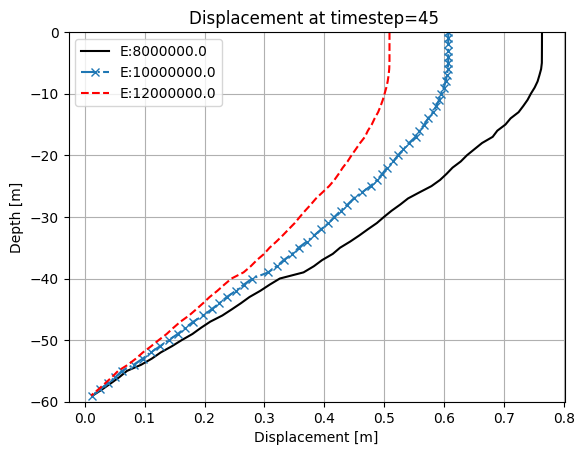

In [6]:
pvd_1A=vtuIO.PVDIO("Stiffness="+str(stiffness_mean_list[0][0])+'.pvd', dim=2)
pvd_1B=vtuIO.PVDIO("Stiffness="+str(stiffness_mean_list[1][0])+'.pvd', dim=2)
pvd_1C=vtuIO.PVDIO("Stiffness="+str(stiffness_mean_list[2][0])+'.pvd', dim=2)

func_1A = pvd_1A.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1B = pvd_1B.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1C = pvd_1C.read_set_data(time, "displacement", pointsetarray=xaxis)

plt.plot(func_1A[:, 1],r_x, label='E:'+str(stiffness_mean_list[0][0]), color='k')
plt.plot(func_1B[:, 1],r_x, label='E:'+str(stiffness_mean_list[1][0]), linestyle='-.', marker="x")
plt.plot(func_1C[:, 1],r_x, label='E:'+str(stiffness_mean_list[2][0]), linestyle='--', color='r')

title_str="Displacement at timestep={} ".format(time)
plt.title(title_str)

#plt.xscale('log')
plt.ylim(-60,0)
plt.ylabel('Depth [m]')
plt.xlabel('Displacement [m]')

plt.legend()
plt.grid()
plt.show()

In [10]:
#restore default settings for domain_with_stiffness.vtu
os.chdir('..')
pm.execute_notebook('generate_mesh_2D_cell_RF.ipynb','generate_mesh_2D_cell_RF_variant.ipynb',parameters=dict(stiffness_mean=[1e7]))

Executing:   0%|          | 0/36 [00:00<?, ?cell/s]

{'cells': [{'cell_type': 'markdown',
   'id': 'e422f479-4d4f-4932-9e87-f19947ed6575',
   'metadata': {'tags': [],
    'papermill': {'exception': False,
     'start_time': '2024-11-27T12:04:18.001348',
     'end_time': '2024-11-27T12:04:18.036829',
     'duration': 0.035481,
     'status': 'completed'}},
   'source': 'This script is to construct a simple 2D underground model, that contains a mesh, with artificial dataset of a ground property (e.g. stiffness) and scale of fluctuation. '},
  {'cell_type': 'code',
   'execution_count': 1,
   'id': 'acd9f838-9e92-4ede-a58c-cd31a1577ad5',
   'metadata': {'tags': [],
    'papermill': {'exception': False,
     'start_time': '2024-11-27T12:04:18.051336',
     'end_time': '2024-11-27T12:04:24.063245',
     'duration': 6.011909,
     'status': 'completed'},
    'execution': {'iopub.status.busy': '2024-11-27T12:04:18.052862Z',
     'iopub.execute_input': '2024-11-27T12:04:18.052862Z',
     'iopub.status.idle': '2024-11-27T12:04:24.063245Z',
     '

### Solid Density

We change the density in the prj file

In [ ]:
densities = [2.6e3, 2.8e3, 3.0e3]  #2.6e3

for density in densities: 
    model = ogs.OGS(INPUT_FILE=file, PROJECT_FILE=file, MKL=True)
    model.replace_text("out_solid_density="+str(density), xpath="./time_loop/output/prefix")
    
    model.replace_text("if (y >= -50, 0.3/(1-0.3)*(1-0.35)*"+str(density)+"*9.81*y, 0.3/(1-0.3)*((1-0.35)*"+str(density)+"*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=1)
    model.replace_text("if (y >= -50, (1-0.35)*"+str(density)+"*9.81*y, ((1-0.35)*"+str(density)+"*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=2)
    model.replace_text("if (y >= -50, 0.3/(1-0.3)*(1-0.35)*"+str(density)+"*9.81*y, 0.3/(1-0.3)*((1-0.35)*"+str(density)+"*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=3)

    model.replace_phase_property_value(mediumid=0, phase='Solid', name="density", value=density)
    model.write_input()
    model.run_model(logfile="out.txt")


OGS finished with project file input.prj.
Execution took 9.127113103866577 s
Project file written to output.
OGS finished with project file input.prj.
Execution took 9.025639295578003 s
Project file written to output.
OGS finished with project file input.prj.
Execution took 9.12693166732788 s
Project file written to output.


We read the pvd and plot.

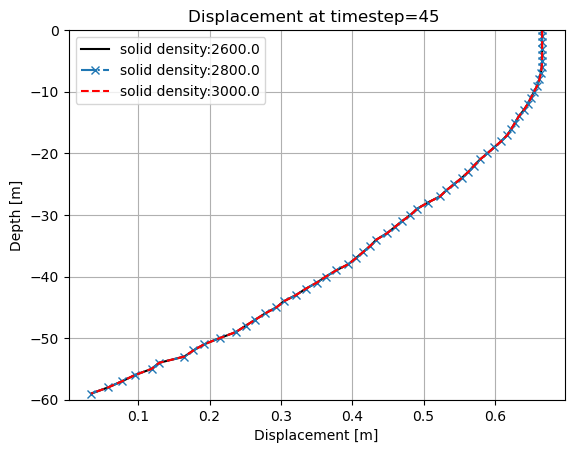

In [ ]:
pvd_1A=vtuIO.PVDIO("out_solid_density="+str(densities[0])+'.pvd', dim=2)
pvd_1B=vtuIO.PVDIO("out_solid_density="+str(densities[1])+'.pvd', dim=2)
pvd_1C=vtuIO.PVDIO("out_solid_density="+str(densities[2])+'.pvd', dim=2)

func_1A = pvd_1A.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1B = pvd_1B.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1C = pvd_1C.read_set_data(time, "displacement", pointsetarray=xaxis)

plt.plot(func_1A[:, 1, ],r_x, label='solid density:'+str(densities[0]), color='k')
plt.plot(func_1B[:, 1],r_x, label='solid density:'+str(densities[1]), linestyle='-.', marker="x")
plt.plot(func_1C[:, 1],r_x, label='solid density:'+str(densities[2]), linestyle='--', color='r')

title_str="Displacement at timestep={} ".format(time)
plt.title(title_str)

#plt.xscale('log')
plt.ylim(-60,0)
plt.ylabel('Depth [m]')
plt.xlabel('Displacement [m]')

plt.legend()
plt.grid()
plt.show()

In [ ]:
# restore default settings
model = ogs.OGS(INPUT_FILE=file, PROJECT_FILE=file, MKL=True)
model.replace_phase_property_value(mediumid=0, phase='Solid', name="density", value=2.6e3)
model.write_input()


True

### Porosity

In [ ]:
phis = [0.30, 0.35, 0.40]   #0.35

for phi in phis:
    model = ogs.OGS(INPUT_FILE=file, PROJECT_FILE=file, MKL=True)
    model.replace_text("out_porosity="+str(phi), xpath="./time_loop/output/prefix")

    model.replace_text("if (y >= -50, 0.3/(1-0.3)*(1-"+str(phi)+")*2600*9.81*y, 0.3/(1-0.3)*((1-"+str(phi)+")*2600*y + "+str(phi)+"*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=1)
    model.replace_text("if (y >= -50, (1-"+str(phi)+")*2600*9.81*y, ((1-"+str(phi)+")*2600*y + "+str(phi)+"*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=2)
    model.replace_text("if (y >= -50, 0.3/(1-0.3)*(1-"+str(phi)+")*2600*9.81*y, 0.3/(1-0.3)*((1-"+str(phi)+")*2600*y + "+str(phi)+"*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=3)

    model.replace_medium_property_value(mediumid=0, name="porosity", value=phi)
    model.write_input()
    model.run_model(logfile="out.txt")

OGS finished with project file input.prj.
Execution took 9.144378662109375 s
Project file written to output.
OGS finished with project file input.prj.
Execution took 9.0254225730896 s
Project file written to output.
OGS finished with project file input.prj.
Execution took 9.119071960449219 s
Project file written to output.


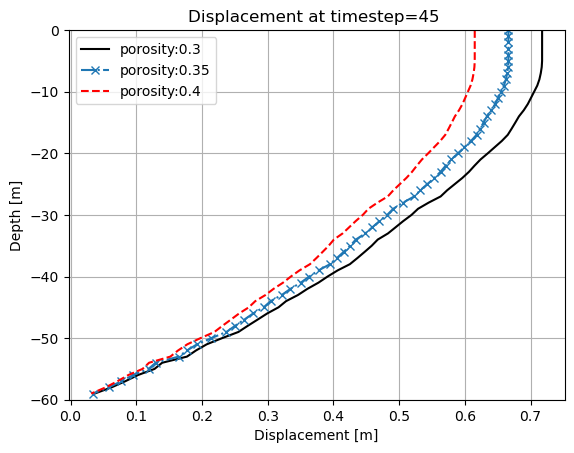

In [ ]:
pvd_1A=vtuIO.PVDIO("out_porosity="+str(phis[0])+'.pvd', dim=2)
pvd_1B=vtuIO.PVDIO("out_porosity="+str(phis[1])+'.pvd', dim=2)
pvd_1C=vtuIO.PVDIO("out_porosity="+str(phis[2])+'.pvd', dim=2)

func_1A = pvd_1A.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1B = pvd_1B.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1C = pvd_1C.read_set_data(time, "displacement", pointsetarray=xaxis)

plt.plot(func_1A[:, 1],r_x, label='porosity:'+str(phis[0]), color='k')
plt.plot(func_1B[:, 1],r_x, label='porosity:'+str(phis[1]), linestyle='-.', marker="x")
plt.plot(func_1C[:, 1],r_x, label='porosity:'+str(phis[2]), linestyle='--', color='r')

title_str="Displacement at timestep={} ".format(time)
plt.title(title_str)

#plt.xscale('log')
plt.ylim(-60,0)
plt.ylabel('Depth [m]')
plt.xlabel('Displacement [m]')

plt.legend()
plt.grid()
plt.show()

In [ ]:
# restore default settings
model = ogs.OGS(INPUT_FILE=file, PROJECT_FILE=file, MKL=True)
model.replace_medium_property_value(mediumid=0, name="porosity", value=0.35)
model.write_input()

### Poisson's ratio

In [ ]:
nus =[0.2, 0.25, 0.3] #0.3

for nu in nus:
    model = ogs.OGS(INPUT_FILE=file, PROJECT_FILE=file, MKL=True)
    model.replace_text("out_nu="+str(nu), xpath="./time_loop/output/prefix")

    model.replace_text("if (y >= -50, "+str(nu)+"/(1-"+str(nu)+")*(1-0.35)*2600*9.81*y, "+str(nu)+"/(1-"+str(nu)+")*((1-0.35)*2600*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=1)
    model.replace_text("if (y >= -50, (1-0.35)*2600*9.81*y, ((1-0.35)*2600*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=2)
    model.replace_text("if (y >= -50, "+str(nu)+"/(1-"+str(nu)+")*(1-0.35)*2600*9.81*y, "+str(nu)+"/(1-"+str(nu)+")*((1-0.35)*2600*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=3)

    model.replace_parameter_value(name="nu", value=nu)
    model.write_input()
    model.run_model(logfile="out.txt")

OGS finished with project file input.prj.
Execution took 11.132630348205566 s
Project file written to output.
OGS finished with project file input.prj.
Execution took 9.046830415725708 s
Project file written to output.
OGS finished with project file input.prj.
Execution took 9.07575798034668 s
Project file written to output.


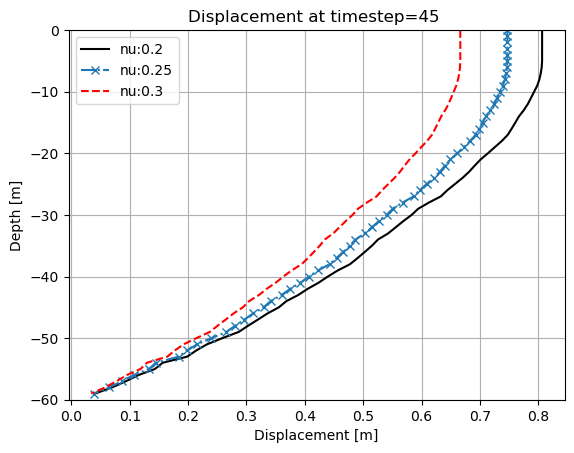

In [ ]:
pvd_1A=vtuIO.PVDIO("out_nu="+str(nus[0])+'.pvd', dim=2)
pvd_1B=vtuIO.PVDIO("out_nu="+str(nus[1])+'.pvd', dim=2)
pvd_1C=vtuIO.PVDIO("out_nu="+str(nus[2])+'.pvd', dim=2)

func_1A = pvd_1A.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1B = pvd_1B.read_set_data(time, "displacement", pointsetarray=xaxis)
func_1C = pvd_1C.read_set_data(time, "displacement", pointsetarray=xaxis)

plt.plot(func_1A[:, 1],r_x, label='nu:'+str(nus[0]), color='k')
plt.plot(func_1B[:, 1],r_x, label='nu:'+str(nus[1]), linestyle='-.', marker="x")
plt.plot(func_1C[:, 1],r_x, label='nu:'+str(nus[2]), linestyle='--', color='r')

title_str="Displacement at timestep={} ".format(time)
plt.title(title_str)

#plt.xscale('log')
plt.ylim(-60,0)
plt.ylabel('Depth [m]')
plt.xlabel('Displacement [m]')

plt.legend()
plt.grid()
plt.show()

In [ ]:
# restore default settings
model = ogs.OGS(INPUT_FILE=file, PROJECT_FILE=file, MKL=True)
model.replace_parameter_value(name="nu", value=0.3)

model.replace_text("if (y >= -50, 0.3/(1-0.3)*(1-0.35)*2600*9.81*y, 0.3/(1-0.3)*((1-0.35)*2600*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=1)
model.replace_text("if (y >= -50, (1-0.35)*2600*9.81*y, ((1-0.35)*2600*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=2)
model.replace_text("if (y >= -50, 0.3/(1-0.3)*(1-0.35)*2600*9.81*y, 0.3/(1-0.3)*((1-0.35)*2600*y + 0.35*1000*(y+50))*9.81)", xpath="./parameters/parameter/expression", occurrence=3)

# replace original name for our last sensitivity analysis
model.replace_text("uplift", xpath="./time_loop/output/prefix")

model.write_input()
os.chdir('..')
